# The Waiver Radar, step by step

This notebook walks through the first module of Two-Minute Warning: the **Waiver Radar**. It is
written for someone in their first fantasy season who is also learning how to test a prediction
honestly. Every number below is computed from the project's own files when the notebook runs;
nothing is typed in by hand.

What you need before running it (all local, nothing is downloaded):

```bash
uv run twm radar dataset                                  # the pool, features and labels
uv run twm radar backtest --label y_hit --label y_sustained   # every past prediction
uv run twm radar evaluate                                 # the report and the figures
uv run jupyter lab notebooks/01_waiver_radar.ipynb
```

The notebook only **reads**: the dataset (`data/waiver_radar/dataset.parquet`), the predictions
store (`data/predictions.duckdb`, opened read-only) and the committed reports. It re-predicts
nothing, so what you see here is exactly what the time machine and the report show. Longer
explanations: `docs/waiver_radar.md`; every number: `reports/waiver_radar/evaluation.md`.

In [1]:
import io
import json
import os
import tempfile
from pathlib import Path

import duckdb
import polars as pl
from IPython.display import Image, Markdown, display
from matplotlib.figure import Figure
from matplotlib.patches import Patch, Rectangle

from twm.backtest.walkforward import TestSeasonInTrainingError, assert_before, plan_folds
from twm.config import ROOT, league
from twm.modules.waiver_radar import evaluation as ev
from twm.modules.waiver_radar import figures as figs
from twm.modules.waiver_radar.models import model_rows

os.chdir(ROOT)  # every path below is relative to the project folder
pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_tbl_rows(25)
pl.Config.set_fmt_str_lengths(60)

DATASET = Path("data/waiver_radar/dataset.parquet")
STORE = Path("data/predictions.duckdb")
REPORTS = Path("reports/waiver_radar")


def pct(x, digits=1):
    return f"{100 * x:.{digits}f}%"


dataset = pl.read_parquet(DATASET)
rows = model_rows(dataset)  # the rows the models learn from and are graded on
print(
    f"{dataset.height:,} player-weeks in the dataset, seasons "
    f"{dataset['season'].min()}-{dataset['season'].max()}; "
    f"{rows.height:,} of them are pool rows with a known outcome"
)

134,113 player-weeks in the dataset, seasons 2013-2026; 96,220 of them are pool rows with a known outcome


## 1. What the Waiver Radar answers

In a 12-team league every team drafts its roster in the summer. The players nobody drafted sit on
the **waiver wire** and can be picked up during the season. Each week a few of them suddenly
matter: a starter gets hurt, a rookie earns more snaps, a backup takes over the team's carries.
The managers who add those players early win leagues.

Every **Tuesday** of the season (after Monday night's game, before the next week's games), the
Radar looks at the players who are probably still on waivers and ranks them, one list per
position (QB, RB, WR, TE), by the chance that they become a **fantasy starter** soon.

"Starter" has a precise meaning here: a player **finishes a week in the top 12 at QB or TE, or the
top 24 at RB or WR**. Those are the numbers a 12-team league starts each week (12 teams x 1 QB,
12 x 2 RBs ...). "Soon" means in his team's **next 3 games**.

The cell below shows those thresholds (from `config/league.yaml`) and how big the lists are on a
typical Tuesday.

In [2]:
lg = league()
print("starter finish = weekly rank at or better than:", dict(lg.starter_rank_threshold))
example = dataset.filter((pl.col("season") == 2023) & (pl.col("week") == 6) & pl.col("in_pool"))
sizes = example.group_by("position").len().sort("position")
print("players the Radar ranked on the Tuesday after week 6 of 2023, by position:")
sizes

starter finish = weekly rank at or better than: {'QB': 12, 'RB': 24, 'WR': 24, 'TE': 12}
players the Radar ranked on the Tuesday after week 6 of 2023, by position:


position,len
str,u32
"""QB""",75
"""RB""",117
"""TE""",128
"""WR""",226


## 2. The pool: who is "probably on waivers"?

A real league knows exactly who is on waivers. Past seasons do not: nobody saved which players
sat on fantasy rosters week by week before 2020. To test the Radar on 12 past seasons, we need a
rule that says "probably available" and works the same way in every season. This stand-in is
called a **proxy**.

The rule (step C1, the owner's choice): a player is in the pool when he is **outside the top N at
his position by both** a preseason ranking **and** his fantasy points per game so far this season.
A player ranked that high before the season was drafted in almost every league; a player
scoring that well has been picked up by now. N is 1.5 times the starter number: QB 18, RB 36,
WR 36, TE 18. Before 2020 there are no preseason rankings, so last season's points per game
stand in for them.

**Does the proxy match reality?** From 2020 on, FantasyPros saved how many leagues rostered each
player. Calling a player "really available" when he was rostered in fewer than 50% of leagues,
the proxy can be checked (numbers from `reports/waiver_radar/pool_sizes.csv`):

In [3]:
lg_cut = league().candidate_pool_cutoffs()
print("pool cut-offs (outside the top N by both lists):", lg_cut)
sizes = pl.read_csv(REPORTS / "pool_sizes.csv")
ecr = sizes.filter((pl.col("method") == "ecr") & (pl.col("season") <= 2025))  # complete seasons
checked = ecr.select(
    pl.sum("n_pool_owned_below").alias("pool_and_available"),
    pl.sum("n_pool_owned_at_least").alias("pool_but_rostered"),
    pl.sum("n_out_owned_below").alias("not_pool_but_available"),
).row(0, named=True)
precision = checked["pool_and_available"] / (
    checked["pool_and_available"] + checked["pool_but_rostered"]
)
recall = checked["pool_and_available"] / (
    checked["pool_and_available"] + checked["not_pool_but_available"]
)
seasons = ecr["season"]
display(
    Markdown(
        f"In {seasons.min()}-{seasons.max()}, **{pct(precision)}** of the pool players with a "
        f"rostership figure really were available (precision), and the pool contained "
        f"**{pct(recall)}** of the really available players (recall), over "
        f"{sum(checked.values()):,} player-weeks. So the proxy is right about "
        f"{round(25 * precision)} times in 25; the few pool players that real leagues had rostered "
        "are handled in section 6."
    )
)

pool cut-offs (outside the top N by both lists): {'QB': 18, 'RB': 36, 'WR': 36, 'TE': 18}


In 2020-2025, **95.6%** of the pool players with a rostership figure really were available (precision), and the pool contained **95.7%** of the really available players (recall), over 34,531 player-weeks. So the proxy is right about 24 times in 25; the few pool players that real leagues had rostered are handled in section 6.

## 3. The label: what counts as a hit?

To grade a prediction you need the right answer. For every pool player on every Tuesday, the
**label** records what really happened in his next 3 games (step C2):

- **`y_hit`**: at least **one** starter finish in those 3 games (the Radar's main target);
- **`y_sustained`**: at least **two** (a new starter, not a one-week spike).

A bye week does not count as one of the 3 games (the window moves one week further). The label is
built only from games played **after** that Tuesday, so it can never leak into the features.

How often does a pool player hit? That is the **base rate**: the success rate of picking pool
players at random, the floor every method must beat.

In [4]:
eval_rows = rows.filter(pl.col("season").is_between(2014, 2025))
base = (
    eval_rows.group_by("position")
    .agg(
        pl.len().alias("pool rows"),
        pl.col("y_hit").mean().alias("y_hit rate"),
        pl.col("y_sustained").mean().alias("y_sustained rate"),
    )
    .sort("position")
)
total = eval_rows.select(
    pl.lit("all").alias("position"),
    pl.len().alias("pool rows"),
    pl.col("y_hit").mean().alias("y_hit rate"),
    pl.col("y_sustained").mean().alias("y_sustained rate"),
)
table = pl.concat([base, total]).with_columns(
    pl.col("y_hit rate").map_elements(pct, return_dtype=pl.String),
    pl.col("y_sustained rate").map_elements(pct, return_dtype=pl.String),
)
one_in = round(1 / eval_rows["y_hit"].mean())
two_in = round(1 / eval_rows["y_sustained"].mean())
display(
    Markdown(
        f"2014-2025: about **1 pool player in {one_in}** has a starter week within 3 games, "
        f"and about **1 in {two_in}** has two."
    )
)
table

2014-2025: about **1 pool player in 9** has a starter week within 3 games, and about **1 in 41** has two.

position,pool rows,y_hit rate,y_sustained rate
str,u32,str,str
"""QB""",13099,"""9.2%""","""2.5%"""
"""RB""",20826,"""13.0%""","""3.7%"""
"""TE""",20847,"""9.5%""","""1.9%"""
"""WR""",36866,"""10.4%""","""2.1%"""
"""all""",91638,"""10.6%""","""2.5%"""


## 4. Features: what the Radar knows on Tuesday

A **feature** is one number describing a player's situation on that Tuesday, using only what
was public then (step C3 registers 49 of them; `docs/glossary.md` explains each). They come in
families: **opportunity** (how much he plays and is thrown to or handed the ball: snap share,
target share, carry share, expected fantasy points), **role change** (teammates who became
unavailable and the opportunity they leave behind, depth-chart moves), **context** (team offense,
upcoming opponents, byes) and the **player** (age, rookie, draft round).

Which features separate hits from misses on their own? The **AUC** below is the chance that a
random hit has a higher value than a random miss (0.5 = no signal, 1.0 = perfect). It is a quick
check, not a model (`reports/waiver_radar/features.csv`):

In [5]:
auc = pl.read_csv(REPORTS / "features.csv")
strongest = (
    auc.with_columns((pl.col("auc") - 0.5).abs().alias("signal"))
    .sort(["position", "signal"], descending=[False, True])
    .group_by("position", maintain_order=True)
    .head(4)
    .select("position", "feature", "family", "auc")
)
strongest

position,feature,family,auc
str,str,str,f64
"""QB""","""snap_share_season""","""opportunity""",0.8698
"""QB""","""xfp_avg3""","""opportunity""",0.8644
"""QB""","""snap_share_avg3""","""opportunity""",0.8616
"""QB""","""routes_proxy_avg3""","""opportunity""",0.8592
"""RB""","""xfp_avg3""","""opportunity""",0.8246
"""RB""","""carry_share_avg3""","""opportunity""",0.8211
"""RB""","""fantasy_points_avg3""","""opportunity""",0.8201
"""RB""","""xfp_last""","""opportunity""",0.7994
"""TE""","""wopr_avg3""","""opportunity""",0.8307


Opportunity dominates: most pool players are deep backups who barely play, so "does he play at
all, and is the ball coming to him" separates a lot. The **teammate** features look weak on their
own because a starter's injury matters only for the player next in line, not for the whole pool.
The model combines them with his own snaps. Here is one real case from the dataset: the Tuesday
after week 11 of 2014, in Denver, the pool players whose teammate ahead of them was out:

In [6]:
case = dataset.filter(
    (pl.col("season") == 2014)
    & (pl.col("week") == 11)
    & (pl.col("team") == "DEN")
    & pl.col("in_pool")
    & pl.col("top_teammate_out")
).sort("snap_share_delta", descending=True)
player = case.row(0, named=True)
out = json.loads(player["teammates_out"])
same_pos = [t for t in out if t["position"] == player["position"]]
for t in same_pos:
    snaps, carries = pct(t["snap_share_avg3"], 0), pct(t["carry_share_avg3"], 0)
    print(
        f"teammate out: {t['name']} ({t['position']}), why: {t['rules']}; "
        f"his last 3 games: {snaps} of the snaps, {carries} of the carries"
    )
snaps, jump = pct(player["snap_share_last"], 0), 100 * player["snap_share_delta"]
print(
    f"{player['name']} ({player['position']}) in his last game: {snaps} of the snaps "
    f"(up {jump:.0f} points), {pct(player['carry_share_last'], 0)} of the carries"
)
con = duckdb.connect(str(STORE), read_only=True)
radar = con.execute(
    "SELECT p.rank, p.score FROM predictions p JOIN model_versions v USING (model_version) "
    "WHERE v.model = 'logit' AND v.label = 'y_hit' "
    "AND p.entity_id = ? AND p.season = ? AND p.week = ?",
    [player["gsis_id"], player["season"], player["week"]],
).fetchall()
con.close()
if radar:
    print(
        f"the Radar that Tuesday: rank {radar[0][0]} among {player['position']}s, "
        f"chance of a starter week {pct(radar[0][1], 0)}"
    )
print(
    "what happened, his weekly rank at",
    player["position"],
    "in weeks",
    player["window_weeks"],
    ":",
    player["window_ranks"],
    "-> y_hit =",
    player["y_hit"],
    ", y_sustained =",
    player["y_sustained"],
)

teammate out: Ronnie Hillman (RB), why: injury_report+missed_last_game; his last 3 games: 60% of the snaps, 49% of the carries
C.J. Anderson (RB) in his last game: 93% of the snaps (up 68 points), 90% of the carries
the Radar that Tuesday: rank 2 among RBs, chance of a starter week 71%
what happened, his weekly rank at RB in weeks [12, 13, 14] : [2, 3, 7] -> y_hit = True , y_sustained = True


## 5. Walk-forward: testing the honest way

A model graded on games it learned from looks brilliant and is useless. So every past prediction
was made the way it would have been made live (step C4):

- To grade **season S**, the model learns **only from seasons before S**, then ranks every
  Tuesday of S. Then the same for S+1, learning from one more season. This is a **walk-forward**
  test: twelve seasons (2014-2025) of predictions, none of which the model had seen.
- Its settings are chosen on the **last season before S** (the validation season), and its
  probabilities are calibrated there too.
- Every feature is read **point-in-time**: only rows that were public at that Tuesday
  (`twm.asof.AsOfView`). A **leak detector** (`twm.backtest.leakage.assert_future_invariant`)
  reruns a feature after deleting or scrambling everything that happened later; if the feature
  changes, it was peeking at the future and the test fails.

The picture shows which seasons each test season learned from:

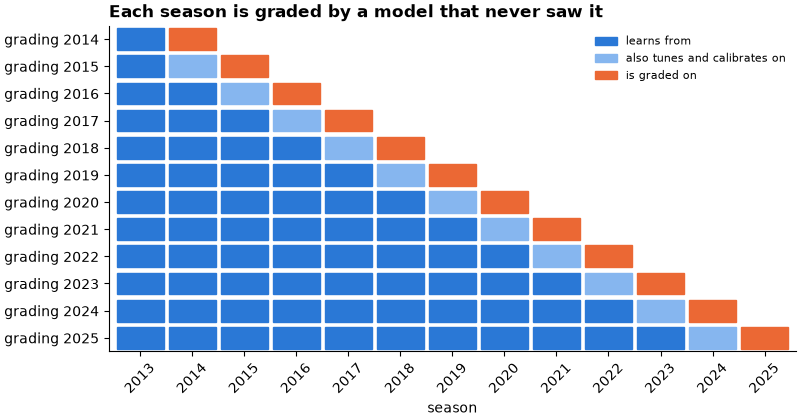

In [7]:
folds = plan_folds(range(2013, 2026), range(2014, 2026))
colors = {"train": "#2a78d6", "validate": "#86b6ef", "test": "#eb6834"}
fig = Figure(figsize=(8, 4.2), dpi=100, layout="constrained")
ax = fig.subplots()
for i, f in enumerate(folds):
    for s in range(2013, 2026):
        role = (
            "test"
            if s == f.test_season
            else "validate"
            if s == f.val_season
            else "train"
            if s in f.train_seasons
            else None
        )
        if role:
            ax.add_patch(Rectangle((s - 0.45, i - 0.4), 0.9, 0.8, color=colors[role]))
ax.set_xlim(2012.4, 2025.6)
ax.set_ylim(len(folds) - 0.5, -0.5)
ax.set_yticks(range(len(folds)), [f"grading {f.test_season}" for f in folds])
ax.set_xticks(range(2013, 2026), [str(s) for s in range(2013, 2026)], rotation=45)
ax.set_xlabel("season")
ax.spines[["top", "right"]].set_visible(False)
handles = [
    Patch(color=colors["train"], label="learns from"),
    Patch(color=colors["validate"], label="also tunes and calibrates on"),
    Patch(color=colors["test"], label="is graded on"),
]
ax.legend(handles=handles, loc="upper right", frameon=False, fontsize=8)
ax.set_title("Each season is graded by a model that never saw it", loc="left", fontweight="bold")
png = io.BytesIO()
fig.savefig(png, format="png", metadata={"Software": None})
display(Image(png.getvalue()))

The harness **refuses** to break that rule. If any row of the test season (or later) reaches a
model, it stops with an error instead of producing a flattering number:

In [8]:
leaky = pl.DataFrame({"season": [2018, 2019, 2020], "snap_share_last": [0.4, 0.7, 0.9]})
try:
    assert_before(leaky, 2020, what="train the 2020 model")
except TestSeasonInTrainingError as err:
    print("refused:", err)

refused: refusing to train the 2020 model: 1 row(s) of season(s) [2020] are not before the test season 2020. A model graded on season 2020 may only learn from earlier seasons (PROJECT_SPEC 6.2 rule 2).


## 6. Results: how good is the Radar?

The main grade is **precision@10**: of the 10 players the Radar ranks highest at a position on a
Tuesday, how many got a starter week in their next 3 games? It is computed for every weekly list
(12 seasons x about 15 Tuesdays x 4 positions = 732 lists) and averaged.

Two baselines show whether the model adds anything: **last week's points** (what most people look
at) and the **snap-share change** (a jump in playing time). The **experts** (FantasyPros' ranks,
2020 on) are compared on the weeks they covered.

How sure can we be? Twelve seasons are a small sample, so each number comes with a **95%
interval** from the **season-block bootstrap**: draw 12 seasons at random from the 12 (some twice,
some not at all), recompute, repeat 2,000 times, keep the middle 95%. Whole seasons are drawn
because the weeks of one season are linked (same players, same model). If the interval of a
difference stays above zero, the gap is not luck.

In [9]:
evals = {lb: ev.evaluate_label(ev.load(STORE, dataset, lb)) for lb in ("y_hit", "y_sustained")}
hit = evals["y_hit"]
full = f"{hit.seasons[0]}-{hit.seasons[-1]}"


def pooled_table(e, subset):
    out = []
    for m in e.full_methods:
        r = e.one(subset=subset, model=m, scope="pooled", seasons=full, metric="p_at_10")
        out.append(
            {
                "method": ev.TITLES[m],
                "precision@10": pct(r["value"]),
                "95% interval": f"{pct(r['lo'])} to {pct(r['hi'])}",
                "top-10 picks that hit": f"{r['n_top_hits']:,} of {r['n_top']:,}",
                "lists": r["n_groups"],
            }
        )
    return pl.DataFrame(out)


pooled_table(hit, "all")

method,precision@10,95% interval,top-10 picks that hit,lists
str,str,str,str,i64
"""logistic regression""","""47.8%""","""46.2% to 49.5%""","""3,501 of 7,320""",732
"""LightGBM""","""47.6%""","""45.9% to 49.6%""","""3,483 of 7,320""",732
"""last week's points""","""40.4%""","""38.8% to 42.0%""","""2,956 of 7,320""",732
"""snap-share change""","""24.6%""","""23.1% to 26.2%""","""1,804 of 7,320""",732


In [10]:
w = hit.winner
r = hit.one(subset="all", model=w, scope="pooled", seasons=full, metric="p_at_10")
d = hit.one(
    subset="all",
    model=w,
    scope="diff",
    seasons=full,
    key="baseline_last_points",
    metric="p_at_10_diff",
)
won = hit.one(
    subset="all",
    model=w,
    scope="diff",
    seasons=full,
    key="baseline_last_points",
    metric="seasons_won",
)
base = hit.one(subset="all", model="base_rate", scope="pooled", seasons=full)
display(
    Markdown(
        f"**What this means for a manager.** If you had picked up the Radar's top 10 at a "
        f"position every Tuesday of {full}, about **{r['value'] * 10:.0f} of those 10** would "
        f"have given you a starter week within three games ({pct(r['value'])}; 95% interval "
        f"{pct(r['lo'])} to {pct(r['hi'])}). Picking pool players at random: about "
        f"{base['value'] * 10:.0f} in 10 ({pct(base['value'])}). The Radar beats last week's "
        f"points by **{100 * d['value']:.1f} points** (95% interval {100 * d['lo']:+.1f} to "
        f"{100 * d['hi']:+.1f}), and did so in **{int(won['value'])} of {won['n_groups']} "
        "seasons**."
    )
)

**What this means for a manager.** If you had picked up the Radar's top 10 at a position every Tuesday of 2014-2025, about **5 of those 10** would have given you a starter week within three games (47.8%; 95% interval 46.2% to 49.5%). Picking pool players at random: about 1 in 10 (10.6%). The Radar beats last week's points by **7.4 points** (95% interval +6.2 to +8.7), and did so in **12 of 12 seasons**.

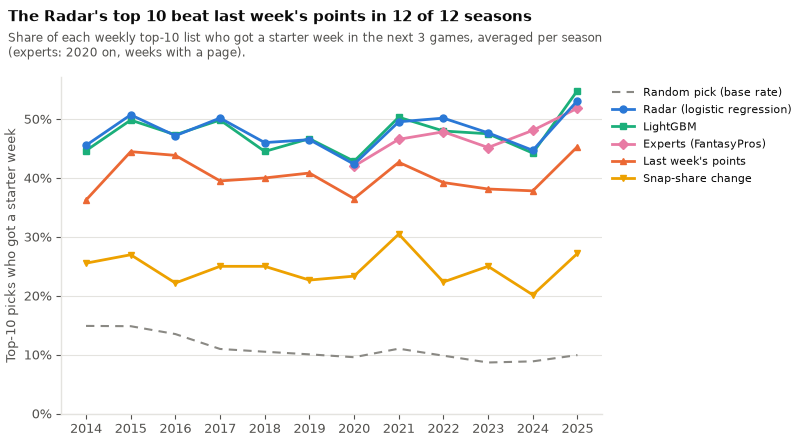

In [11]:
fig_dir = Path(tempfile.mkdtemp())
paths = {p.stem: p for p in figs.write_figures(list(evals.values()), fig_dir)}
display(Image(filename=paths["precision_by_season"]))

The title counts the seasons in which the Radar's line (blue) was above last week's points
(orange); the dashed line is a random pick. The experts (pink) exist from 2020 on.

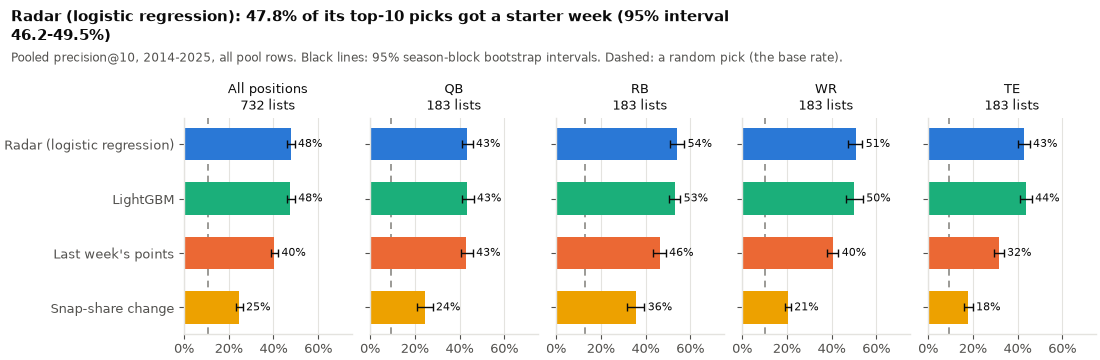

In [12]:
display(Image(filename=paths["precision_pooled"]))

In [13]:
rows_ = []
for pos in ("QB", "RB", "WR", "TE"):
    x = hit.one(
        subset="all",
        model=w,
        scope="position_diff",
        key=f"{pos} vs baseline_last_points",
        metric="p_at_10_diff",
    )
    rows_.append(
        {
            "position": pos,
            "Radar minus last week's points": f"{100 * x['value']:+.1f} points",
            "95% interval": f"{100 * x['lo']:+.1f} to {100 * x['hi']:+.1f}",
        }
    )
display(pl.DataFrame(rows_))
unclear = [
    pos
    for pos in ("QB", "RB", "WR", "TE")
    if (
        x := hit.one(
            subset="all",
            model=w,
            scope="position_diff",
            key=f"{pos} vs baseline_last_points",
            metric="p_at_10_diff",
        )
    )["lo"]
    <= 0
]
why = (
    " At quarterback that is no surprise: a pool QB who scored well last week has usually "
    "just become his team's starter, and last week's points already see that."
    if "QB" in unclear
    else ""
)
display(
    Markdown(
        "**Where it fails, part 1:** at "
        + ", ".join(unclear)
        + " the interval of the gap includes "
        "zero: there the Radar does no better than last week's points." + why
        if unclear
        else "At every position the Radar's lead over last week's points is beyond the noise."
    )
)

position,Radar minus last week's points,95% interval
str,str,str
"""QB""","""+0.3 points""","""-0.6 to +1.3"""
"""RB""","""+7.9 points""","""+5.2 to +10.6"""
"""WR""","""+10.4 points""","""+8.0 to +13.0"""
"""TE""","""+11.1 points""","""+8.6 to +13.5"""


**Where it fails, part 1:** at QB the interval of the gap includes zero: there the Radar does no better than last week's points. At quarterback that is no surprise: a pool QB who scored well last week has usually just become his team's starter, and last week's points already see that.

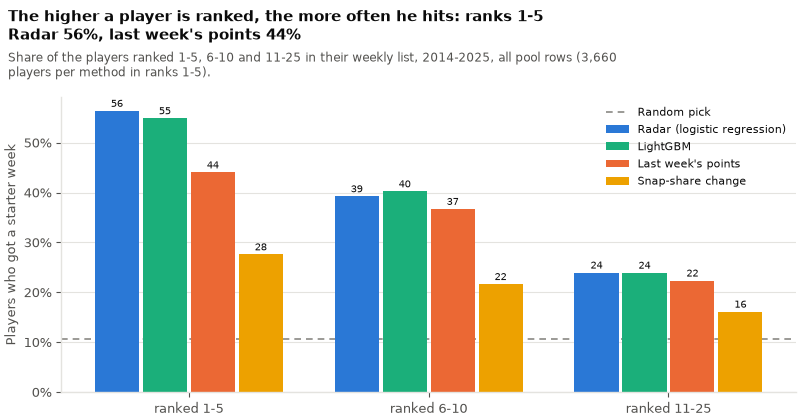

In [14]:
display(Image(filename=paths["hit_rate_by_rank"]))

In [15]:
buckets = ["1-5", "6-10", "11-25"]
radar = [hit.one(subset="all", model=w, scope="bucket", key=b)["value"] for b in buckets]
last = [
    hit.one(subset="all", model="baseline_last_points", scope="bucket", key=b)["value"]
    for b in buckets
]
ordered = radar[0] > radar[1] > radar[2]
display(
    Markdown(
        f"A good ranking puts its best calls first. The Radar's hit rate "
        f"{'falls' if ordered else 'does not fall steadily'} down the list ("
        + ", ".join(f"ranks {b}: {pct(v)}" for b, v in zip(buckets, radar, strict=True))
        + "); its lead over last week's points is "
        + ", ".join(
            f"{100 * (a - b):+.1f} points at ranks {k}"
            for k, a, b in zip(buckets, radar, last, strict=True)
        )
        + ": largest where a manager actually picks, at the top."
    )
)

A good ranking puts its best calls first. The Radar's hit rate falls down the list (ranks 1-5: 56.4%, ranks 6-10: 39.3%, ranks 11-25: 24.0%); its lead over last week's points is +12.3 points at ranks 1-5, +2.5 points at ranks 6-10, +1.6 points at ranks 11-25: largest where a manager actually picks, at the top.

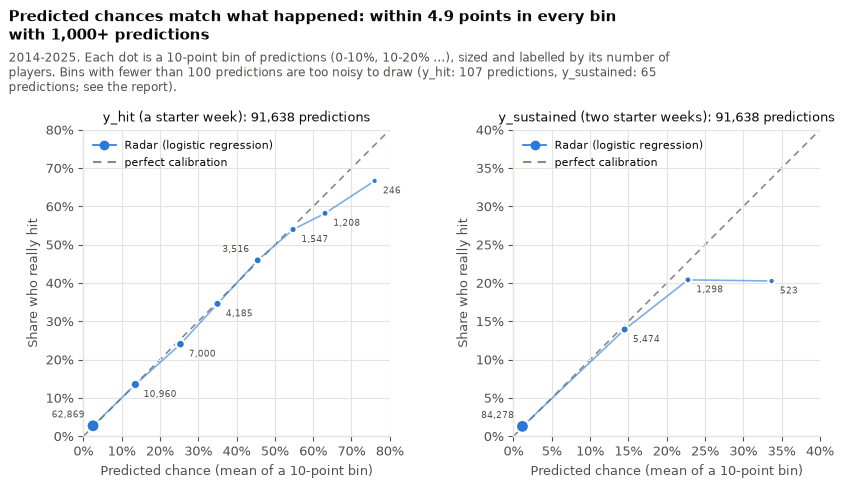

In [16]:
display(Image(filename=paths["calibration"]))

**Can you trust the percentages?** A probability is *calibrated* when "30%" really means that
about 30 of 100 such players hit. The table lists each 10-point bin with its number of
predictions: where the predicted and observed columns part, check how many players are behind
them. A bin of a few dozen players is noise; a gap in a bin of thousands is a real bias.

In [17]:
cal = []
for lb, e in evals.items():
    for b in e.calibration[(e.winner, "fixed")].iter_rows(named=True):
        if b["n"]:
            cal.append(
                {
                    "label": lb,
                    "bin": f"{100 * b['lo']:.0f}-{100 * b['hi']:.0f}%",
                    "predictions": b["n"],
                    "mean predicted": pct(b["mean_pred"]),
                    "observed": pct(b["observed"]),
                    "gap (points)": round(100 * (b["observed"] - b["mean_pred"]), 1),
                }
            )
cal = pl.DataFrame(cal)
big_gaps = cal.filter((pl.col("gap (points)").abs() >= 5) & (pl.col("predictions") >= 100))
display(cal)
display(
    Markdown(
        "Bins with 100+ predictions that miss by 5 points or more: "
        + (
            "; ".join(
                f"`{r['label']}` {r['bin']} ({r['predictions']:,} predictions, "
                f"{r['gap (points)']:+.1f} points)"
                for r in big_gaps.iter_rows(named=True)
            )
            or "none"
        )
        + ". A negative gap means fewer players hit than predicted: read those percentages as "
        "optimistic."
    )
)

label,bin,predictions,mean predicted,observed,gap (points)
str,str,i64,str,str,f64
"""y_hit""","""0-10%""",62869,"""2.5%""","""2.7%""",0.2
"""y_hit""","""10-20%""",10960,"""13.6%""","""13.5%""",-0.1
"""y_hit""","""20-30%""",7000,"""25.3%""","""24.0%""",-1.3
"""y_hit""","""30-40%""",4185,"""35.0%""","""34.6%""",-0.5
"""y_hit""","""40-50%""",3516,"""45.5%""","""45.9%""",0.4
"""y_hit""","""50-60%""",1547,"""54.8%""","""54.0%""",-0.8
"""y_hit""","""60-70%""",1208,"""63.1%""","""58.2%""",-4.9
"""y_hit""","""70-80%""",246,"""76.0%""","""66.7%""",-9.4
"""y_hit""","""80-90%""",66,"""83.5%""","""68.2%""",-15.3


Bins with 100+ predictions that miss by 5 points or more: `y_hit` 70-80% (246 predictions, -9.4 points); `y_sustained` 30-40% (523 predictions, -13.4 points). A negative gap means fewer players hit than predicted: read those percentages as optimistic.

**Where it fails, part 2: the experts and the pool.** FantasyPros' ranks exist from 2020 on;
on the weeks they covered:

In [18]:
e = hit.one(subset="all", model=w, scope="experts_diff", metric="p_at_10_diff")
ew = hit.one(subset="all", model=w, scope="experts_diff", metric="seasons_won")
exp = hit.one(subset="all", model="baseline_ecr", scope="experts", metric="p_at_10")
mine = hit.one(subset="all", model=w, scope="experts", metric="p_at_10")
nr = hit.one(subset="without_rostered", model=w, scope="pooled", seasons=full, metric="p_at_10")
nrb = hit.one(
    subset="without_rostered",
    model="baseline_last_points",
    scope="pooled",
    seasons=full,
    metric="p_at_10",
)
verdict = (
    "The interval includes zero: **the Radar cannot claim to beat the experts**"
    if e["lo"] <= 0
    else "The interval stays above zero: the Radar beat the experts"
)
display(
    Markdown(
        f"- On the {exp['n_groups']} lists the experts covered: Radar {pct(mine['value'])}, "
        f"experts {pct(exp['value'])}; difference {100 * e['value']:+.1f} points, 95% interval "
        f"{100 * e['lo']:+.1f} to {100 * e['hi']:+.1f}. {verdict} (it was ahead in "
        f"{int(ew['value'])} of {ew['n_groups']} seasons).\n"
        "- The proxy pool contains a few players real leagues had rostered (2020 on); they hit "
        f"often and flatter every method. Without them the Radar's precision@10 is "
        f"{pct(nr['value'])} (95% interval {pct(nr['lo'])} to {pct(nr['hi'])}); last week's "
        f"points: {pct(nrb['value'])}."
    )
)

- On the 356 lists the experts covered: Radar 48.4%, experts 46.9%; difference +1.5 points, 95% interval -0.4 to +2.9. The interval includes zero: **the Radar cannot claim to beat the experts** (it was ahead in 5 of 6 seasons).
- The proxy pool contains a few players real leagues had rostered (2020 on); they hit often and flatter every method. Without them the Radar's precision@10 is 45.5% (95% interval 43.6% to 47.5%); last week's points: 38.9%.

**Breakouts caught.** A *breakout* is a pool player who went on to have two starter weeks within
one 3-game window. The Radar *caught* him if it had him in its top 10 on that Tuesday or an
earlier one of the same season (a ranking made after the breakout never counts).

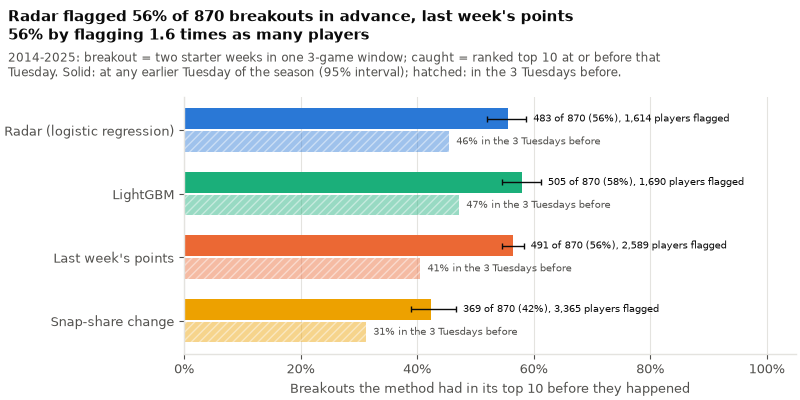

The Radar caught **483 of 870 breakouts** (55.5%); last week's points caught 491 (56.4%): a difference of -0.9 points (95% interval -3.6 to +1.4), so **no better at 'ever in the top 10'**. Keep in mind that last week's points reshuffles its top 10 every week: it put 2,589 different players there, the Radar 1,614. Counting only the 3 Tuesdays before each breakout, the difference is +4.9 points (95% interval +1.7 to +8.2).

In [19]:
display(Image(filename=paths["breakouts_caught"]))
b = hit.one(subset="all", model=w, scope="breakouts", metric="caught_share")
bl = hit.one(subset="all", model="baseline_last_points", scope="breakouts", metric="caught_share")
d = hit.one(
    subset="all",
    model=w,
    scope="breakouts_diff",
    key="baseline_last_points",
    metric="caught_share_diff",
)
dr = hit.one(
    subset="all",
    model=w,
    scope="breakouts_diff",
    key="baseline_last_points",
    metric="caught_recent_share_diff",
)
fw = hit.one(subset="all", model=w, scope="breakouts", metric="players_flagged")
fb = hit.one(
    subset="all", model="baseline_last_points", scope="breakouts", metric="players_flagged"
)
same = d["lo"] <= 0 <= d["hi"]
display(
    Markdown(
        f"The Radar caught **{b['n_pos']} of {b['n_rows']} breakouts** ({pct(b['value'])}); "
        f"last week's points caught {bl['n_pos']} ({pct(bl['value'])}): a difference of "
        f"{100 * d['value']:+.1f} points (95% interval {100 * d['lo']:+.1f} to "
        f"{100 * d['hi']:+.1f})"
        + (", so **no better at 'ever in the top 10'**. " if same else ". ")
        + "Keep in mind that last week's points reshuffles its top 10 every week: it put "
        f"{fb['n_rows']:,} different players there, the Radar {fw['n_rows']:,}. Counting only "
        f"the 3 Tuesdays before each breakout, the difference is {100 * dr['value']:+.1f} points "
        f"(95% interval {100 * dr['lo']:+.1f} to {100 * dr['hi']:+.1f})."
    )
)

In [20]:
def biggest(caught):
    b = ev.biggest_breakouts(hit, caught=caught, n=6)
    extra = dataset.select(
        "season", pl.col("week").alias("breakout_week"), "gsis_id", "prior_season_games"
    )
    return b.join(extra, on=["season", "breakout_week", "gsis_id"], how="left").select(
        "season",
        "name",
        "position",
        "team",
        pl.col("breakout_week").alias("breakout Tuesday after week"),
        pl.col("window_ranks").alias("next 3 weekly ranks"),
        pl.col("rest_starter_weeks").alias("starter weeks after"),
        pl.col("preseason_pos_rank").alias("preseason rank"),
        pl.col("prior_season_games").alias("games last season"),
        pl.col("best_rank").alias("Radar's best rank before"),
    )


print(
    "preseason rank: before 2020 last season's points-per-game rank (a player needs 4+ games "
    "last season; rookies are unranked), from 2020 FantasyPros; empty = unranked"
)
print("the biggest breakouts the Radar caught:")
display(biggest(True))
print("... and the biggest it missed:")
display(biggest(False))

preseason rank: before 2020 last season's points-per-game rank (a player needs 4+ games last season; rookies are unranked), from 2020 FantasyPros; empty = unranked
the biggest breakouts the Radar caught:


season,name,position,team,breakout Tuesday after week,next 3 weekly ranks,starter weeks after,preseason rank,games last season,Radar's best rank before
i32,str,str,str,i32,list[i32],i32,i32,i32,i32
2017,"""Alvin Kamara""","""RB""","""NO""",1,"[32, 17, 6]",13,null,0,2
2018,"""Matt Ryan""","""QB""","""ATL""",1,"[5, 2, 8]",12,22,16,2
2024,"""Bucky Irving""","""RB""","""TB""",2,"[22, 23, 46]",12,54,0,4
2015,"""Gary Barnidge""","""TE""","""CLE""",2,"[2, 4, 3]",12,54,10,5
2023,"""Jerome Ford""","""RB""","""CLE""",1,"[6, 7, 24]",12,58,13,9
2018,"""Andrew Luck""","""QB""","""IND""",2,"[20, 3, 4]",11,null,0,4


... and the biggest it missed:


season,name,position,team,breakout Tuesday after week,next 3 weekly ranks,starter weeks after,preseason rank,games last season,Radar's best rank before
i32,str,str,str,i32,list[i32],i32,i32,i32,i32
2016,"""Jordan Howard""","""RB""","""CHI""",1,"[51, 20, 15]",11,null,0,80
2018,"""Julian Edelman""","""WR""","""NE""",5,"[24, 21, 12]",10,null,0,40
2021,"""Zach Ertz""","""TE""","""PHI""",1,"[53, 7, 12]",10,22,11,11
2020,"""Justin Herbert""","""QB""","""LAC""",2,"[20, 9, 4]",9,35,0,15
2022,"""Tyler Lockett""","""WR""","""SEA""",1,"[15, 21, 26]",9,41,16,14
2025,"""Jacoby Brissett""","""QB""","""ARI""",4,"[33, 7, 12]",9,57,7,21


Look at the `preseason rank` and `games last season` columns. Before 2020 the pool's preseason
list is last season's points per game, so a star who barely played the season before, or a
rookie, is unranked and lands in the pool although every real league drafted him. Such
"breakouts" are the proxy's blind spot, not waiver-wire finds; one more reason to read the
numbers "without rostered" too. The full lists are in `reports/waiver_radar/evaluation.md`.

## 7. Time machine: what the Radar said on one Tuesday

The predictions store keeps every past list, so we can go back to any Tuesday and compare what
the Radar said with what happened. Here: the Tuesday after **week 6 of 2023**, the Radar's top 10
at each position, its chance of a starter week, and each player's weekly rank at his position in
his next 3 games (a starter finish is top 12 at QB/TE, top 24 at RB/WR; empty = no stat line).

In [21]:
SEASON, WEEK = 2023, 6
con = duckdb.connect(str(STORE), read_only=True)
said = con.execute(
    "SELECT p.rank_group AS position, p.rank, p.entity_id AS gsis_id, p.score "
    "FROM predictions p JOIN model_versions v USING (model_version) "
    "WHERE v.model = 'logit' AND v.label = 'y_hit' "
    "AND p.season = ? AND p.week = ? AND p.rank <= 10 "
    "ORDER BY position, rank",
    [SEASON, WEEK],
).pl()
con.close()
then = said.join(
    dataset.filter((pl.col("season") == SEASON) & (pl.col("week") == WEEK)).select(
        "gsis_id", "name", "team", "window_weeks", "window_ranks", "y_hit"
    ),
    on="gsis_id",
    how="left",
)
summary = (
    then.group_by("position")
    .agg(pl.col("y_hit").sum().alias("hits in the top 10"))
    .sort("position")
)
display(
    Markdown(
        "Players in each top 10 who got a starter week in their next 3 games: "
        + ", ".join(
            f"{r['position']} {r['hits in the top 10']}" for r in summary.iter_rows(named=True)
        )
        + "."
    )
)

Players in each top 10 who got a starter week in their next 3 games: QB 3, RB 6, TE 4, WR 7.

In [22]:
view = then.select(
    "position",
    "rank",
    "name",
    "team",
    pl.col("score").map_elements(lambda x: pct(x, 0), return_dtype=pl.String).alias("chance"),
    pl.col("window_ranks").alias("next 3 weekly ranks"),
    pl.when(pl.col("y_hit")).then(pl.lit("yes")).otherwise(pl.lit("no")).alias("hit"),
)
display(view.filter(pl.col("position").is_in(["QB", "RB"])))
display(view.filter(pl.col("position").is_in(["WR", "TE"])))

position,rank,name,team,chance,next 3 weekly ranks,hit
str,i32,str,str,str,list[i32],str
"""QB""",1,"""Bryce Young""","""CAR""","""62%""","[19, 21, 20]","""no"""
"""QB""",2,"""Joshua Dobbs""","""ARI""","""62%""","[13, 8, 4]","""yes"""
"""QB""",3,"""Kenny Pickett""","""PIT""","""62%""","[15, 34, 19]","""no"""
"""QB""",4,"""Matthew Stafford""","""LA""","""62%""","[16, 27, null]","""no"""
"""QB""",5,"""Desmond Ridder""","""ATL""","""62%""","[18, 36, null]","""no"""
"""QB""",6,"""Zach Wilson""","""NYJ""","""62%""","[25, 25, 16]","""no"""
"""QB""",7,"""Derek Carr""","""NO""","""45%""","[10, 13, 11]","""yes"""
"""QB""",8,"""Mac Jones""","""NE""","""43%""","[8, 24, 18]","""yes"""
"""QB""",9,"""Jimmy Garoppolo""","""LV""","""37%""","[null, 33, null]","""no"""


position,rank,name,team,chance,next 3 weekly ranks,hit
str,i32,str,str,str,list[i32],str
"""TE""",1,"""Luke Musgrave""","""GB""","""53%""","[17, 30, 8]","""yes"""
"""TE""",2,"""Jake Ferguson""","""DAL""","""45%""","[10, 4, 6]","""yes"""
"""TE""",3,"""Michael Mayer""","""LV""","""45%""","[28, 30, 33]","""no"""
"""TE""",4,"""Cade Otton""","""TB""","""43%""","[12, 16, 3]","""yes"""
"""TE""",5,"""Tyler Conklin""","""NYJ""","""43%""","[50, 12, 5]","""yes"""
"""TE""",6,"""Dawson Knox""","""BUF""","""37%""","[25, null, null]","""no"""
"""TE""",7,"""Mike Gesicki""","""NE""","""37%""","[14, 29, 47]","""no"""
"""TE""",8,"""Kylen Granson""","""IND""","""28%""","[null, null, 47]","""no"""
"""TE""",9,"""Noah Gray""","""KC""","""28%""","[33, 26, 24]","""no"""


## What next

- **Step C6** turns these rankings into the weekly Radar: every list gets three plain-English
  reasons per player (from the features that pushed his chance up the most) and a suggested
  priority (must-add, speculative, watch).
- Every number here, with its counts and intervals: `reports/waiver_radar/evaluation.md`
  (regenerate with `uv run twm radar evaluate`). How it all works, in plain words:
  `docs/waiver_radar.md`.